# ☕ Coffee Sales — Complete End-to-End Analytics Notebook

---

## 🎯 Project Overview

This notebook delivers a **production-grade, end-to-end data analytics workflow** for a retail coffee business. It covers every phase of the analytics pipeline:

| Phase | Description |
|-------|-------------|
| 📥 **Data Loading** | Flexible loader for local & Kaggle environments |
| 🔍 **Data Quality** | Null analysis, type checks, duplicates |
| 🧹 **Data Cleaning** | Column standardization, type coercion, deduplication |
| ⚙️ **Feature Engineering** | 15+ derived features (time, profit, RFM scores, segments) |
| 📊 **EDA** | 20+ visualizations across products, time, geography, customers |
| 👥 **Customer Segmentation** | RFM scoring + segment labeling + loyalty analysis |
| 💡 **Business Insights** | Actionable recommendations for every finding |

---

**Dataset:** [Coffee Analysis Project — Kaggle](https://www.kaggle.com/datasets/ahmedmohamedibrahim1/coffee-analisys-project/data)  
**Sheets:** `orders` (794 rows) · `customers` (1000 rows) · `products` (48 rows)


---
## 📦 Section 1 — Environment Setup & Library Imports

In [1]:
# ============================================================
# IMPORTS & GLOBAL SETTINGS
# ============================================================
import warnings
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# ── Ensure openpyxl available ──────────────────────────────
try:
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'])
    import openpyxl

# ── Global Plot Style ─────────────────────────────────────
COFFEE_PALETTE = ['#6F4E37', '#C8A97E', '#3E1F00', '#D2691E', '#A0522D',
                  '#8B4513', '#DEB887', '#F5DEB3', '#4A2512', '#B87333']

plt.rcParams.update({
    'figure.facecolor': '#FDFAF6',
    'axes.facecolor':   '#FDFAF6',
    'axes.edgecolor':   '#C8A97E',
    'axes.labelcolor':  '#3E1F00',
    'xtick.color':      '#3E1F00',
    'ytick.color':      '#3E1F00',
    'text.color':       '#3E1F00',
    'grid.color':       '#E8DCC8',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'figure.titlesize': 16,
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('✅ All libraries imported successfully!')
print(f'   numpy  {np.__version__}')
print(f'   pandas {pd.__version__}')
print(f'   seaborn {sns.__version__}')

✅ All libraries imported successfully!
   numpy  1.26.4
   pandas 3.0.1
   seaborn 0.13.2


---
## 📥 Section 2 — Data Loading

In [2]:
# ============================================================
# FLEXIBLE DATA LOADER  (local + Kaggle auto-detect)
# ============================================================

# ── Path candidates (edit local path if running locally) ──
LOCAL_PATH = Path(r'D:/Projects--Kaggle-/Coffee analysis/Dataset/COFFEE_ANALISYS_PROJECT.xlsx')
KAGGLE_PATHS = [
    Path('/kaggle/input/datasets/ahmedmohamedibrahim1/coffee-analisys-project/COFFEE_ANALISYS_PROJECT.xlsx'),
    Path('/kaggle/input/coffee-analisys-project/COFFEE_ANALISYS_PROJECT.xlsx'),
]

file_path = LOCAL_PATH if LOCAL_PATH.exists() else next((p for p in KAGGLE_PATHS if p.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        'Dataset not found.\n'
        'Please update LOCAL_PATH or add the dataset to your Kaggle kernel.'
    )

print(f'✅ File found: {file_path}')

# ── Inspect sheets ─────────────────────────────────────────
xls        = pd.ExcelFile(file_path, engine='openpyxl')
sheet_names = xls.sheet_names
print(f'📋 Sheets: {sheet_names}')

# ── Load the three core sheets ────────────────────────────
def _load(name):
    df = pd.read_excel(file_path, sheet_name=name, engine='openpyxl')
    df.columns = [str(c).strip() for c in df.columns]
    return df

orders_df    = _load('orders')
customers_df = _load('customers')
products_df  = _load('products')

print(f'\n📊 Raw shapes:')
print(f'   orders    : {orders_df.shape}')
print(f'   customers : {customers_df.shape}')
print(f'   products  : {products_df.shape}')

✅ File found: D:\Projects--Kaggle-\Coffee analysis\Dataset\COFFEE_ANALISYS_PROJECT.xlsx
📋 Sheets: ['Top 5 Customer', 'Dashboard', 'Country Barchart', 'Total Sales', 'orders', 'customers', 'products']

📊 Raw shapes:
   orders    : (794, 14)
   customers : (1000, 9)
   products  : (48, 7)


In [3]:
# Quick peek at each table
print('=== ORDERS ===')
display(orders_df.head(3))
print('\n=== CUSTOMERS ===')
display(customers_df.head(3))
print('\n=== PRODUCTS ===')
display(products_df.head(3))

=== ORDERS ===


,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.00,9.95,19.90,Robusta,Medium,Yes
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.50,8.25,41.25,Excelsa,Medium,Yes
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.00,12.95,12.95,Arabica,Large,Yes



=== CUSTOMERS ===


,Customer ID,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card
0,17670-51384-MA,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes
1,73342-18763-UW,Piotr Bote,pbote1@yelp.com,+353 (913) 396-4653,2112 Ridgeway Hill,Crumlin,Ireland,D6W,No
2,21125-22134-PX,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes



=== PRODUCTS ===


,Product ID,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
0,A-L-0.2,Ara,L,0.20,3.88,1.94,0.35
1,A-L-0.5,Ara,L,0.50,7.77,1.55,0.70
2,A-L-1,Ara,L,1.00,12.95,1.29,1.17


---
## 🔍 Section 3 — Data Quality Assessment

In [6]:
# ============================================================
# DATA QUALITY REPORT — per table
# ============================================================

def quality_report(df, name):
    total   = len(df)
    nulls   = df.isnull().sum()
    pct     = (nulls / total * 100).round(2)
    uniques = df.nunique()
    dtypes  = df.dtypes

    report = pd.DataFrame({
        'dtype'       : dtypes,
        'null_count'  : nulls,
        'null_%'      : pct,
        'unique_vals' : uniques,
    })

    dups = df.duplicated().sum()
    print('\n' + '=' * 55)
    print(f'  TABLE: {name}   ({total:,} rows × {df.shape[1]} cols)')
    print(f'  Duplicate rows : {dups}')
    print('=' * 55)
    display(report[report['null_count'] > 0] if report['null_count'].sum() > 0
            else report.head(10))

quality_report(orders_df,    'orders')
quality_report(customers_df, 'customers')
quality_report(products_df,  'products')


  TABLE: orders   (794 rows × 14 cols)
  Duplicate rows : 0


,dtype,null_count,null_%,unique_vals
Order ID,str,0,0.00,758
Order Date,datetime64[us],0,0.00,573
Customer ID,str,0,0.00,726
Product ID,str,0,0.00,48
Quantity,int64,0,0.00,6
Customer Name,str,0,0.00,726
Email,str,0,0.00,726
Country,str,0,0.00,3
Size,float64,0,0.00,4
Unit Price,float64,0,0.00,40



  TABLE: customers   (1,000 rows × 9 cols)
  Duplicate rows : 0


,dtype,null_count,null_%,unique_vals
Email,str,204,20.40,796
Phone Number,str,130,13.00,870



  TABLE: products   (48 rows × 7 cols)
  Duplicate rows : 0


,dtype,null_count,null_%,unique_vals
Product ID,str,0,0.00,48
Coffee Type,str,0,0.00,4
Roast Type,str,0,0.00,3
Size,float64,0,0.00,4
Unit Price,float64,0,0.00,40
Price per 100g,float64,0,0.00,40
Profit,float64,0,0.00,48


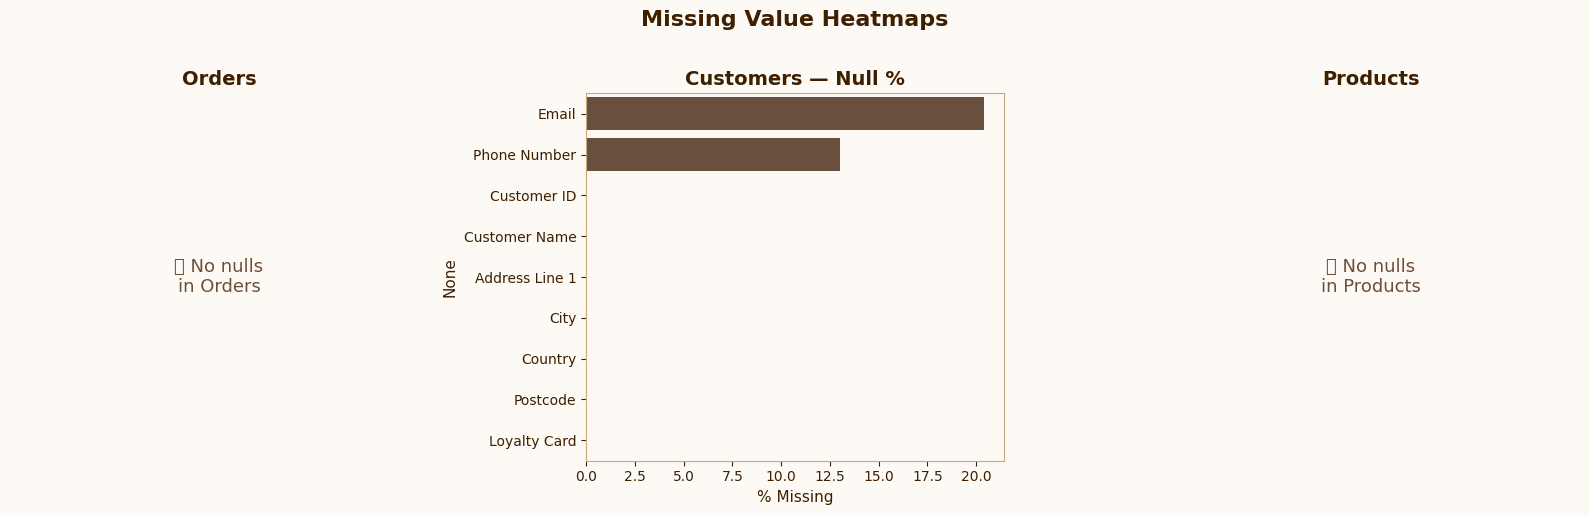

In [7]:
# ── Null heatmap ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Missing Value Heatmaps', fontsize=16, fontweight='bold', y=1.02)

for ax, (df_i, title) in zip(axes, [(orders_df, 'Orders'), (customers_df, 'Customers'), (products_df, 'Products')]):
    null_pct = (df_i.isnull().mean() * 100).sort_values(ascending=False).head(15)
    if null_pct.sum() == 0:
        ax.text(0.5, 0.5, f'✅ No nulls\nin {title}', ha='center', va='center',
                fontsize=13, transform=ax.transAxes, color='#6F4E37')
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
    else:
        sns.barplot(x=null_pct.values, y=null_pct.index, ax=ax, color=COFFEE_PALETTE[0])
        ax.set_title(f'{title} — Null %', fontweight='bold')
        ax.set_xlabel('% Missing')

plt.tight_layout()
plt.show()

---
## 🧹 Section 4 — Data Cleaning & Merging

In [8]:
# ============================================================
# CLEAN + MERGE INTO MASTER DATAFRAME
# ============================================================

# ── 1. Merge orders ← customers ← products ────────────────
cust_cols = [c for c in ['Customer ID', 'City', 'Postcode', 'Country', 'Email', 'Loyalty Card']
             if c in customers_df.columns]
prod_cols = [c for c in ['Product ID', 'Coffee Type', 'Coffee Type Name',
                          'Roast Type Name', 'Size', 'Unit Price', 'Profit']
             if c in products_df.columns]

df = (orders_df
      .merge(customers_df[cust_cols], on='Customer ID', how='left', suffixes=('', '_cust'))
      .merge(products_df[prod_cols],  on='Product ID',  how='left', suffixes=('', '_prod')))

print(f'After merge: {df.shape}')

# ── 2. Date coercion ──────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# ── 3. Numeric coercion ───────────────────────────────────
for col in ['Sales', 'Unit Price', 'Profit', 'Quantity', 'Size']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 4. Drop all-null rows & full duplicates ───────────────
df.drop_duplicates(inplace=True)
df.dropna(how='all', inplace=True)

# ── 5. Derive Sales if missing ────────────────────────────
if 'Sales' not in df.columns and {'Quantity', 'Unit Price'}.issubset(df.columns):
    df['Sales'] = df['Quantity'] * df['Unit Price']

# ── 6. Standardise Loyalty Card ───────────────────────────
if 'Loyalty Card' in df.columns:
    df['Loyalty Card'] = df['Loyalty Card'].astype(str).str.strip().str.title()

print(f'Final shape: {df.shape}')
print('Null summary (top columns):')
display(df.isnull().sum().sort_values(ascending=False).head(8))
display(df.head(3))

After merge: (794, 23)
Final shape: (794, 23)
Null summary (top columns):


Order ID             0
Roast Type Name      0
Unit Price_prod      0
Size_prod            0
Coffee Type          0
Loyalty Card_cust    0
Email_cust           0
Country_cust         0
dtype: int64

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card,City,Postcode,Country_cust,Email_cust,Loyalty Card_cust,Coffee Type,Size_prod,Unit Price_prod,Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.00,9.95,19.90,Robusta,Medium,Yes,Paterson,7505,United States,aallner0@lulu.com,Yes,Rob,1.00,9.95,0.60
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.50,8.25,41.25,Excelsa,Medium,Yes,Paterson,7505,United States,aallner0@lulu.com,Yes,Exc,0.50,8.25,0.91
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.00,12.95,12.95,Arabica,Large,Yes,San Antonio,78205,United States,jredholes2@tmall.com,Yes,Ara,1.00,12.95,1.17


---
## ⚙️ Section 5 — Feature Engineering

In [9]:
# ============================================================
# FEATURE ENGINEERING  — 15+ new columns
# ============================================================

# ── Time Features ─────────────────────────────────────────
df['Year']        = df['Order Date'].dt.year
df['Quarter']     = df['Order Date'].dt.quarter
df['Month_Num']   = df['Order Date'].dt.month
df['Month']       = df['Order Date'].dt.month_name()
df['Day_Name']    = df['Order Date'].dt.day_name()
df['Week']        = df['Order Date'].dt.isocalendar().week.astype('Int64')
df['Is_Weekend']  = df['Day_Name'].isin(['Saturday', 'Sunday'])
df['YearMonth']   = df['Order Date'].dt.to_period('M')

# ── Profit Features ───────────────────────────────────────
if 'Profit' in df.columns and 'Quantity' in df.columns:
    df['Total_Profit'] = df['Profit'] * df['Quantity']

if 'Sales' in df.columns and 'Total_Profit' in df.columns:
    df['Profit_Margin_Pct'] = (df['Total_Profit'] / df['Sales'].replace(0, np.nan) * 100).round(2)

# ── Price Bucket ──────────────────────────────────────────
if 'Unit Price' in df.columns:
    df['Price_Bucket'] = pd.cut(
        df['Unit Price'],
        bins=[0, 7, 10, 14, 999],
        labels=['Budget (<$7)', 'Standard ($7-10)', 'Premium ($10-14)', 'Luxury (>$14)']
    )

# ── Size Label ────────────────────────────────────────────
if 'Size' in df.columns:
    df['Size_Label'] = pd.cut(
        df['Size'],
        bins=[-0.01, 0.3, 0.6, 1.1, 999],
        labels=['Small', 'Medium', 'Large', 'XL']
    )

# ── Season ────────────────────────────────────────────────
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['Season'] = df['Month_Num'].map(season_map)

# ── Revenue Tier per order ────────────────────────────────
if 'Sales' in df.columns:
    df['Revenue_Tier'] = pd.qcut(
        df['Sales'].rank(method='first'),
        q=4,
        labels=['Low', 'Medium', 'High', 'Top']
    )

print(f'✅ Feature engineering complete — total columns: {df.shape[1]}')
new_cols = ['Year','Quarter','Month','Day_Name','Is_Weekend','Season',
            'Total_Profit','Profit_Margin_Pct','Price_Bucket','Size_Label','Revenue_Tier']
display(df[[c for c in new_cols if c in df.columns]].head(5))

✅ Feature engineering complete — total columns: 37


,Year,Quarter,Month,Day_Name,Is_Weekend,Season,Total_Profit,Profit_Margin_Pct,Price_Bucket,Size_Label,Revenue_Tier
0,2019,3,September,Thursday,False,Autumn,1.19,6.00,Standard ($7-10),Large,Medium
1,2019,3,September,Thursday,False,Autumn,4.54,11.00,Standard ($7-10),Medium,High
2,2021,2,June,Thursday,False,Summer,1.17,9.00,Premium ($10-14),Large,Low
3,2022,1,January,Friday,False,Winter,2.41,11.00,Standard ($7-10),Medium,Medium
4,2019,1,January,Wednesday,False,Winter,1.07,6.00,Budget (<$7),Medium,Medium


---
## 📊 Section 6 — Exploratory Data Analysis (EDA)

### 6.1 — Executive KPI Summary

In [10]:
# ============================================================
# KPI SUMMARY TABLE
# ============================================================

total_sales    = df['Sales'].sum()             if 'Sales'        in df.columns else 0
total_profit   = df['Total_Profit'].sum()      if 'Total_Profit' in df.columns else 0
total_orders   = df['Order ID'].nunique()      if 'Order ID'     in df.columns else len(df)
total_customers= df['Customer Name'].nunique() if 'Customer Name' in df.columns else 0
avg_order_val  = total_sales / total_orders    if total_orders > 0 else 0
avg_margin_pct = (total_profit / total_sales * 100) if total_sales > 0 else 0

kpis = pd.DataFrame({
    'KPI'  : ['Total Revenue', 'Total Profit', 'Total Orders',
               'Unique Customers', 'Avg Order Value', 'Profit Margin %'],
    'Value': [f'${total_sales:,.2f}', f'${total_profit:,.2f}', f'{total_orders:,}',
               f'{total_customers:,}', f'${avg_order_val:,.2f}', f'{avg_margin_pct:.1f}%'],
})

print('\n' + '☕  EXECUTIVE KPI DASHBOARD  ☕'.center(55))
print('='*55)
display(kpis.style.set_properties(**{'text-align':'left'})
             .set_table_styles([{'selector':'th', 'props':[('background-color','#6F4E37'),
                                                            ('color','white')]}]))


             ☕  EXECUTIVE KPI DASHBOARD  ☕             


,KPI,Value
0,Total Revenue,"$34,788.15"
1,Total Profit,"$3,474.84"
2,Total Orders,758
3,Unique Customers,726
4,Avg Order Value,$45.89
5,Profit Margin %,10.0%


### 6.2 — Product Analysis

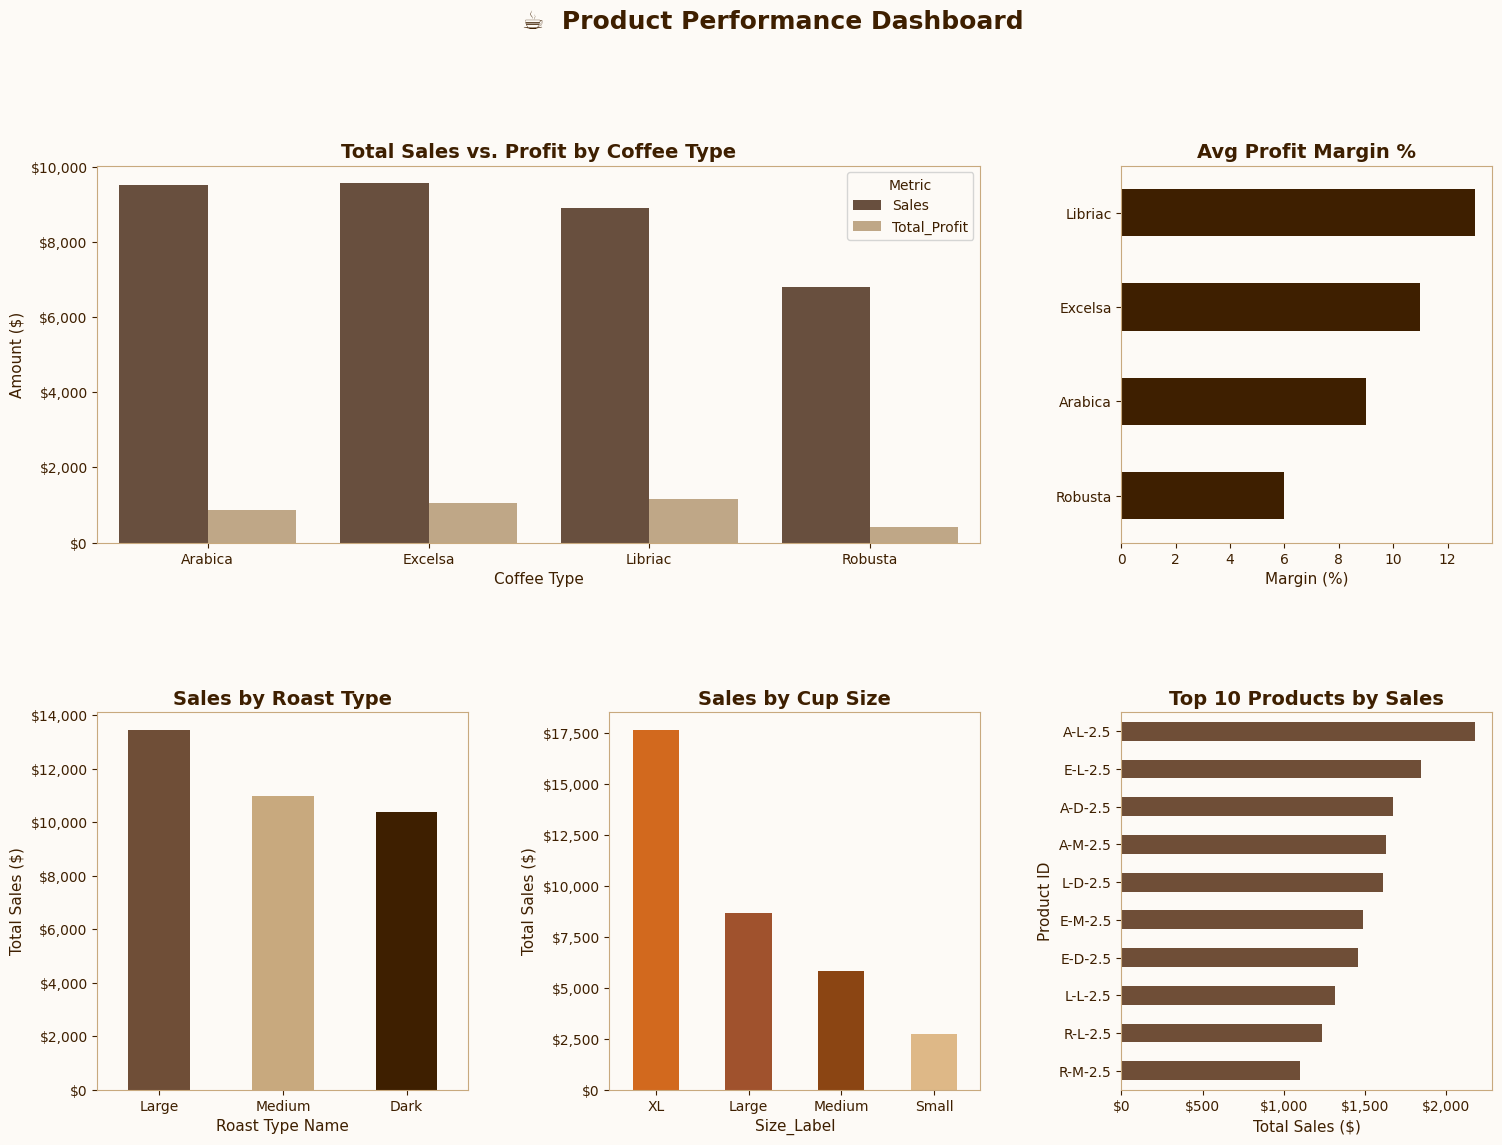

In [11]:
# ============================================================
# PRODUCT ANALYSIS  — Sales + Profit by coffee type & roast
# ============================================================

coffee_col = 'Coffee Type Name' if 'Coffee Type Name' in df.columns else 'Coffee Type'
roast_col  = 'Roast Type Name'  if 'Roast Type Name'  in df.columns else None

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('☕  Product Performance Dashboard', fontsize=18, fontweight='bold', y=1.01)

# ── A: Sales & Profit by coffee type ─────────────────────
ax1 = fig.add_subplot(gs[0, :2])
if coffee_col in df.columns:
    ct = df.groupby(coffee_col)[['Sales', 'Total_Profit']].sum().reset_index()
    ct_melt = ct.melt(id_vars=coffee_col, var_name='Metric', value_name='Amount')
    palette_2 = {'Sales': COFFEE_PALETTE[0], 'Total_Profit': COFFEE_PALETTE[1]}
    sns.barplot(data=ct_melt, x=coffee_col, y='Amount', hue='Metric',
                palette=palette_2, ax=ax1)
    ax1.set_title('Total Sales vs. Profit by Coffee Type', fontweight='bold')
    ax1.set_xlabel('Coffee Type')
    ax1.set_ylabel('Amount ($)')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.legend(title='Metric')

# ── B: Profit Margin % by coffee type ────────────────────
ax2 = fig.add_subplot(gs[0, 2])
if coffee_col in df.columns and 'Profit_Margin_Pct' in df.columns:
    margin = df.groupby(coffee_col)['Profit_Margin_Pct'].mean().sort_values(ascending=True)
    margin.plot(kind='barh', ax=ax2, color=COFFEE_PALETTE[2])
    ax2.set_title('Avg Profit Margin %', fontweight='bold')
    ax2.set_xlabel('Margin (%)')
    ax2.set_ylabel('')

# ── C: Sales by Roast Type ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
if roast_col and roast_col in df.columns:
    roast = df.groupby(roast_col)['Sales'].sum().sort_values(ascending=False)
    roast.plot(kind='bar', ax=ax3, color=COFFEE_PALETTE[:len(roast)], rot=0)
    ax3.set_title('Sales by Roast Type', fontweight='bold')
    ax3.set_ylabel('Total Sales ($)')
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── D: Sales by Size ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if 'Size_Label' in df.columns:
    size_s = df.groupby('Size_Label', observed=True)['Sales'].sum().sort_values(ascending=False)
    size_s.plot(kind='bar', ax=ax4, color=COFFEE_PALETTE[3:7], rot=0)
    ax4.set_title('Sales by Cup Size', fontweight='bold')
    ax4.set_ylabel('Total Sales ($)')
    ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── E: Top 10 Products ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
if 'Product ID' in df.columns:
    top_prod = df.groupby('Product ID')['Sales'].sum().sort_values(ascending=False).head(10)
    top_prod.plot(kind='barh', ax=ax5, color=COFFEE_PALETTE[0])
    ax5.set_title('Top 10 Products by Sales', fontweight='bold')
    ax5.set_xlabel('Total Sales ($)')
    ax5.invert_yaxis()
    ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.savefig('product_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 — Time-Series & Trend Analysis

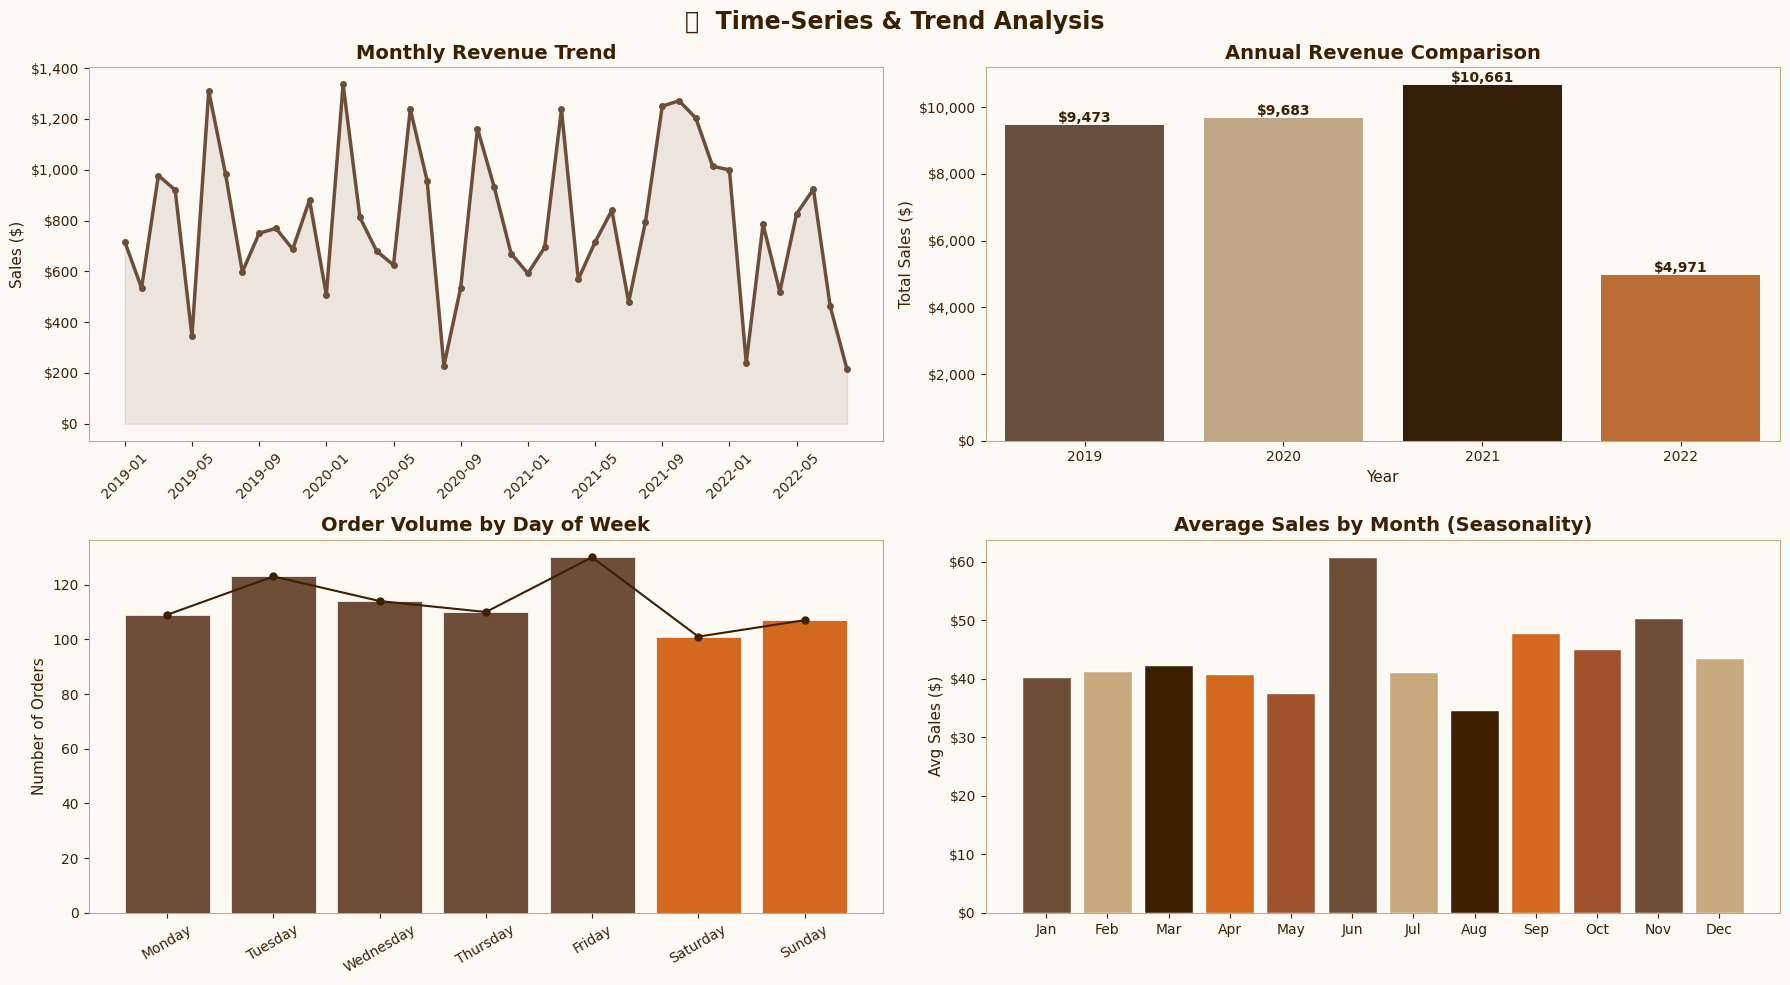

In [12]:
# ============================================================
# TIME-SERIES ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('📅  Time-Series & Trend Analysis', fontsize=17, fontweight='bold')

# ── A: Monthly revenue trend ──────────────────────────────
ax = axes[0, 0]
if 'YearMonth' in df.columns:
    monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()
    monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)
    ax.plot(monthly['YearMonth_str'], monthly['Sales'],
            color=COFFEE_PALETTE[0], linewidth=2.5, marker='o', markersize=4)
    ax.fill_between(monthly['YearMonth_str'], monthly['Sales'],
                    color=COFFEE_PALETTE[0], alpha=0.12)
    ax.set_title('Monthly Revenue Trend', fontweight='bold')
    ax.set_ylabel('Sales ($)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    step = max(1, len(monthly) // 10)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(monthly['YearMonth_str'].iloc[::step], rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── B: Sales by Year ──────────────────────────────────────
ax = axes[0, 1]
if 'Year' in df.columns:
    annual = df.groupby('Year')['Sales'].sum().reset_index()
    sns.barplot(data=annual, x='Year', y='Sales', palette=COFFEE_PALETTE[:len(annual)],
                ax=ax)
    ax.set_title('Annual Revenue Comparison', fontweight='bold')
    ax.set_ylabel('Total Sales ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    for p in ax.patches:
        ax.annotate(f'${p.get_height():,.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── C: Day-of-week order volume ───────────────────────────
ax = axes[1, 0]
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
if 'Day_Name' in df.columns:
    daily = df['Day_Name'].value_counts().reindex(day_order).fillna(0)
    colors_dow = [COFFEE_PALETTE[0] if d not in ['Saturday','Sunday'] else COFFEE_PALETTE[3]
                  for d in day_order]
    ax.bar(daily.index, daily.values, color=colors_dow, edgecolor='white', linewidth=0.5)
    ax.plot(daily.index, daily.values, color='#3E1F00', linewidth=1.5,
            marker='o', markersize=5, zorder=5)
    ax.set_title('Order Volume by Day of Week', fontweight='bold')
    ax.set_ylabel('Number of Orders')
    ax.tick_params(axis='x', rotation=30)

# ── D: Monthly seasonality (avg across all years) ────────
ax = axes[1, 1]
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
if 'Month' in df.columns:
    monthly_avg = df.groupby('Month')['Sales'].mean().reindex(month_order).fillna(0)
    ax.bar(range(len(monthly_avg)), monthly_avg.values,
           color=[COFFEE_PALETTE[i % 5] for i in range(12)],
           edgecolor='white')
    ax.set_xticks(range(12))
    ax.set_xticklabels([m[:3] for m in month_order], rotation=0)
    ax.set_title('Average Sales by Month (Seasonality)', fontweight='bold')
    ax.set_ylabel('Avg Sales ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('time_series.png', dpi=150, bbox_inches='tight')
plt.show()

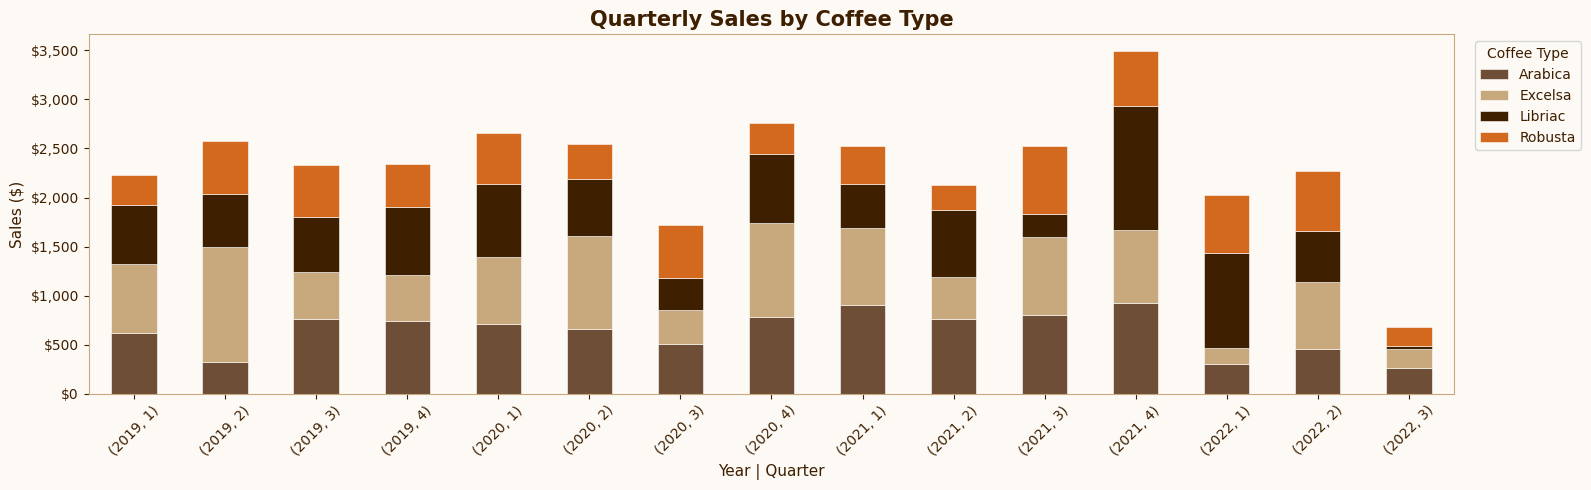

In [13]:
# ── Quarterly sales by coffee type (stacked area) ─────────

if coffee_col in df.columns and {'Year','Quarter'}.issubset(df.columns):
    pivot = (df.groupby(['Year','Quarter', coffee_col])['Sales']
               .sum()
               .unstack(coffee_col)
               .fillna(0))

    fig, ax = plt.subplots(figsize=(16, 5))
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=COFFEE_PALETTE[:len(pivot.columns)],
               edgecolor='white', linewidth=0.4)

    ax.set_title('Quarterly Sales by Coffee Type', fontsize=15, fontweight='bold')
    ax.set_xlabel('Year | Quarter')
    ax.set_ylabel('Sales ($)')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.legend(title='Coffee Type', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('quarterly_stacked.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6.4 — Geographic Analysis

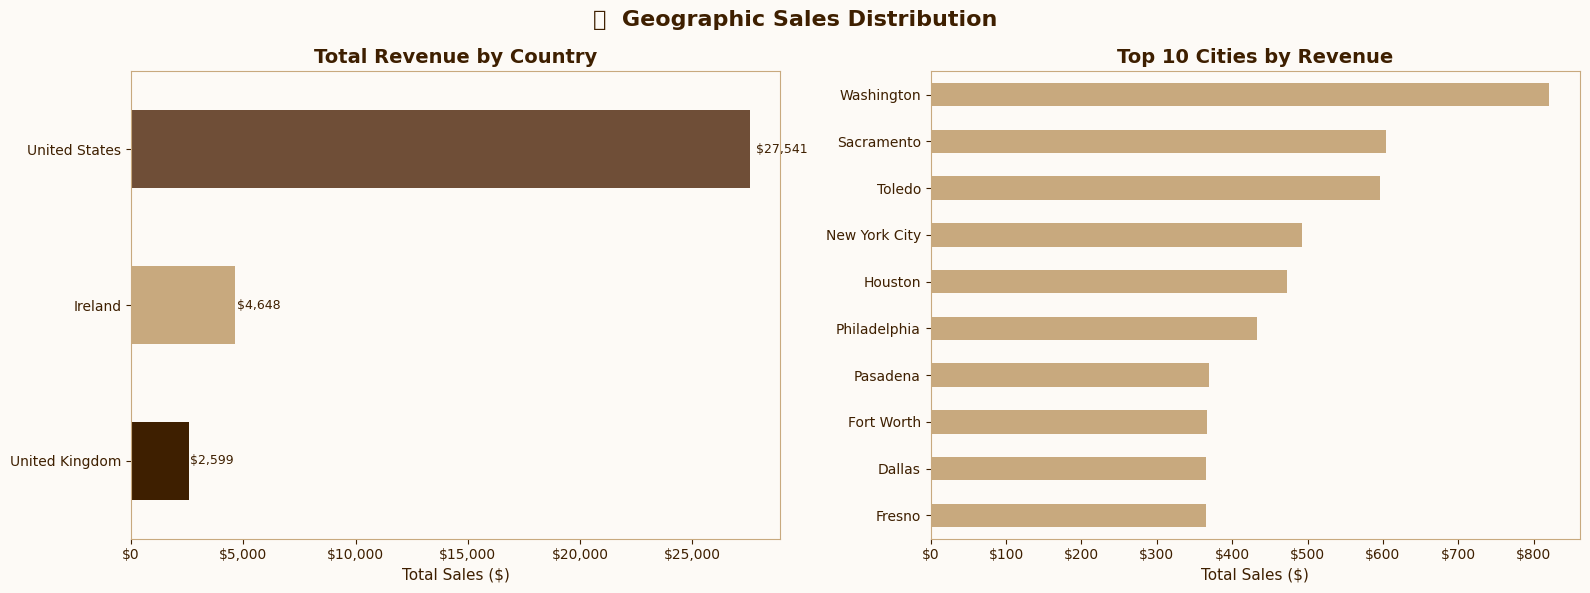

In [14]:
# ============================================================
# GEOGRAPHIC ANALYSIS
# ============================================================

country_col = 'Country_x' if 'Country_x' in df.columns else 'Country'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🌍  Geographic Sales Distribution', fontsize=16, fontweight='bold')

# ── A: Sales by Country ───────────────────────────────────
ax = axes[0]
if country_col in df.columns:
    by_country = df.groupby(country_col)['Sales'].sum().sort_values(ascending=False)
    by_country.plot(kind='barh', ax=ax,
                    color=COFFEE_PALETTE[:len(by_country)])
    ax.set_title('Total Revenue by Country', fontweight='bold')
    ax.set_xlabel('Total Sales ($)')
    ax.set_ylabel('')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    for i, v in enumerate(by_country.values):
        ax.text(v * 1.01, i, f'${v:,.0f}', va='center', fontsize=9)

# ── B: Top 10 cities ──────────────────────────────────────
ax = axes[1]
if 'City' in df.columns:
    by_city = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
    by_city.plot(kind='barh', ax=ax, color=COFFEE_PALETTE[1])
    ax.set_title('Top 10 Cities by Revenue', fontweight='bold')
    ax.set_xlabel('Total Sales ($)')
    ax.set_ylabel('')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('geo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 — Sales Distribution & Statistical Analysis

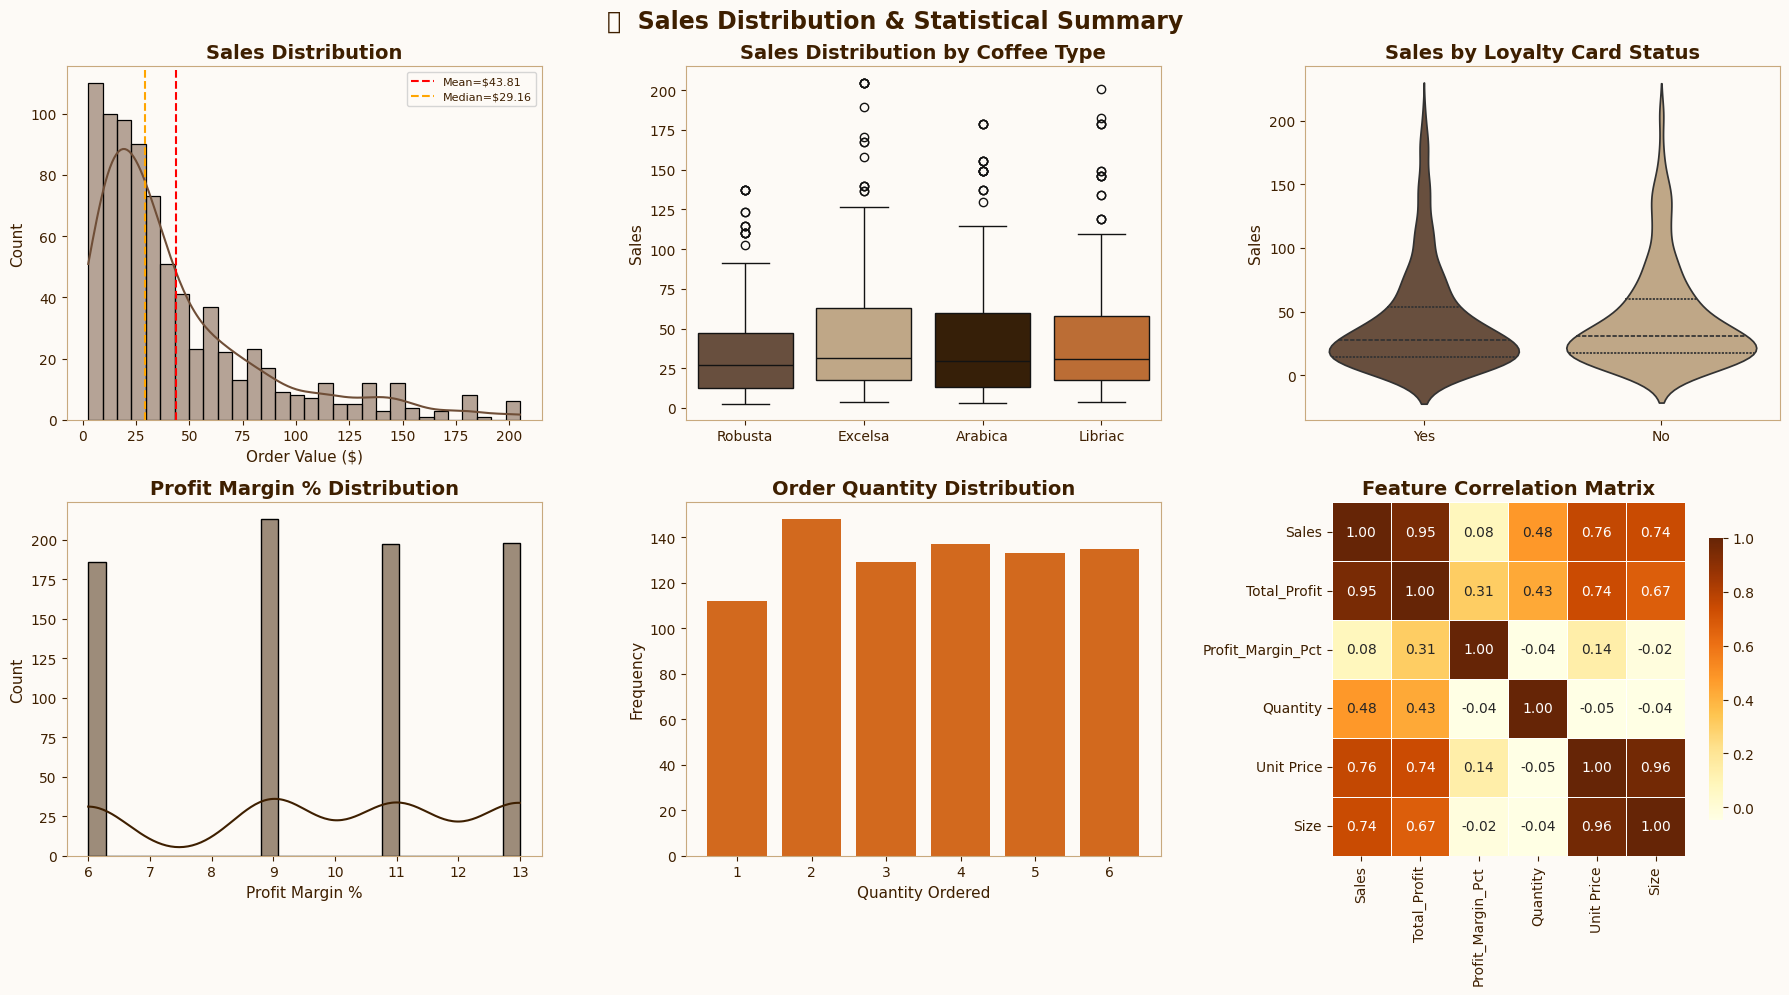


📋 Descriptive Statistics:


,Sales,Total_Profit,Profit_Margin_Pct,Quantity,Unit Price,Size
count,794.00,794.00,794.00,794.00,794.00,794.00
mean,43.81,4.38,9.79,3.55,12.56,1.01
std,41.08,4.46,2.54,1.68,9.55,0.87
min,2.68,0.16,6.00,1.00,2.68,0.20
25%,15.54,1.38,9.00,2.00,4.76,0.20
50%,29.16,2.84,9.00,4.00,8.91,0.50
75%,59.40,5.88,11.00,5.00,15.85,1.00
max,204.93,26.10,13.00,6.00,36.46,2.50


In [15]:
# ============================================================
# DISTRIBUTION & STATISTICAL ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📈  Sales Distribution & Statistical Summary', fontsize=17, fontweight='bold')

# ── A: Sales histogram + KDE ──────────────────────────────
ax = axes[0, 0]
if 'Sales' in df.columns:
    sns.histplot(df['Sales'].dropna(), bins=30, kde=True,
                 color=COFFEE_PALETTE[0], ax=ax)
    ax.axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean=${df["Sales"].mean():.2f}')
    ax.axvline(df['Sales'].median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median=${df["Sales"].median():.2f}')
    ax.set_title('Sales Distribution', fontweight='bold')
    ax.set_xlabel('Order Value ($)')
    ax.legend(fontsize=8)

# ── B: Box-plot by coffee type ────────────────────────────
ax = axes[0, 1]
if coffee_col in df.columns and 'Sales' in df.columns:
    sns.boxplot(data=df, x=coffee_col, y='Sales',
                palette=COFFEE_PALETTE[:4], ax=ax)
    ax.set_title('Sales Distribution by Coffee Type', fontweight='bold')
    ax.set_xlabel('')

# ── C: Violin — sales by Loyalty ──────────────────────────
ax = axes[0, 2]
if 'Loyalty Card' in df.columns and 'Sales' in df.columns:
    sns.violinplot(data=df, x='Loyalty Card', y='Sales',
                   palette=[COFFEE_PALETTE[0], COFFEE_PALETTE[1]], ax=ax, inner='quartile')
    ax.set_title('Sales by Loyalty Card Status', fontweight='bold')
    ax.set_xlabel('')

# ── D: Profit margin histogram ────────────────────────────
ax = axes[1, 0]
if 'Profit_Margin_Pct' in df.columns:
    sns.histplot(df['Profit_Margin_Pct'].dropna(), bins=25, kde=True,
                 color=COFFEE_PALETTE[2], ax=ax)
    ax.set_title('Profit Margin % Distribution', fontweight='bold')
    ax.set_xlabel('Profit Margin %')

# ── E: Quantity histogram ────────────────────────────────
ax = axes[1, 1]
if 'Quantity' in df.columns:
    qty_counts = df['Quantity'].value_counts().sort_index()
    ax.bar(qty_counts.index.astype(str), qty_counts.values,
           color=COFFEE_PALETTE[3])
    ax.set_title('Order Quantity Distribution', fontweight='bold')
    ax.set_xlabel('Quantity Ordered')
    ax.set_ylabel('Frequency')

# ── F: Correlation heatmap ────────────────────────────────
ax = axes[1, 2]
num_cols = df.select_dtypes(include='number').columns.tolist()
key_cols = [c for c in ['Sales','Total_Profit','Profit_Margin_Pct','Quantity',
                         'Unit Price','Size'] if c in num_cols]
if len(key_cols) > 1:
    corr = df[key_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrBr',
                ax=ax, linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8})
    ax.set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Descriptive statistics table ──────────────────────────
print('\n📋 Descriptive Statistics:')
display(df[key_cols].describe().round(2))

### 6.6 — Loyalty Card Deep Dive

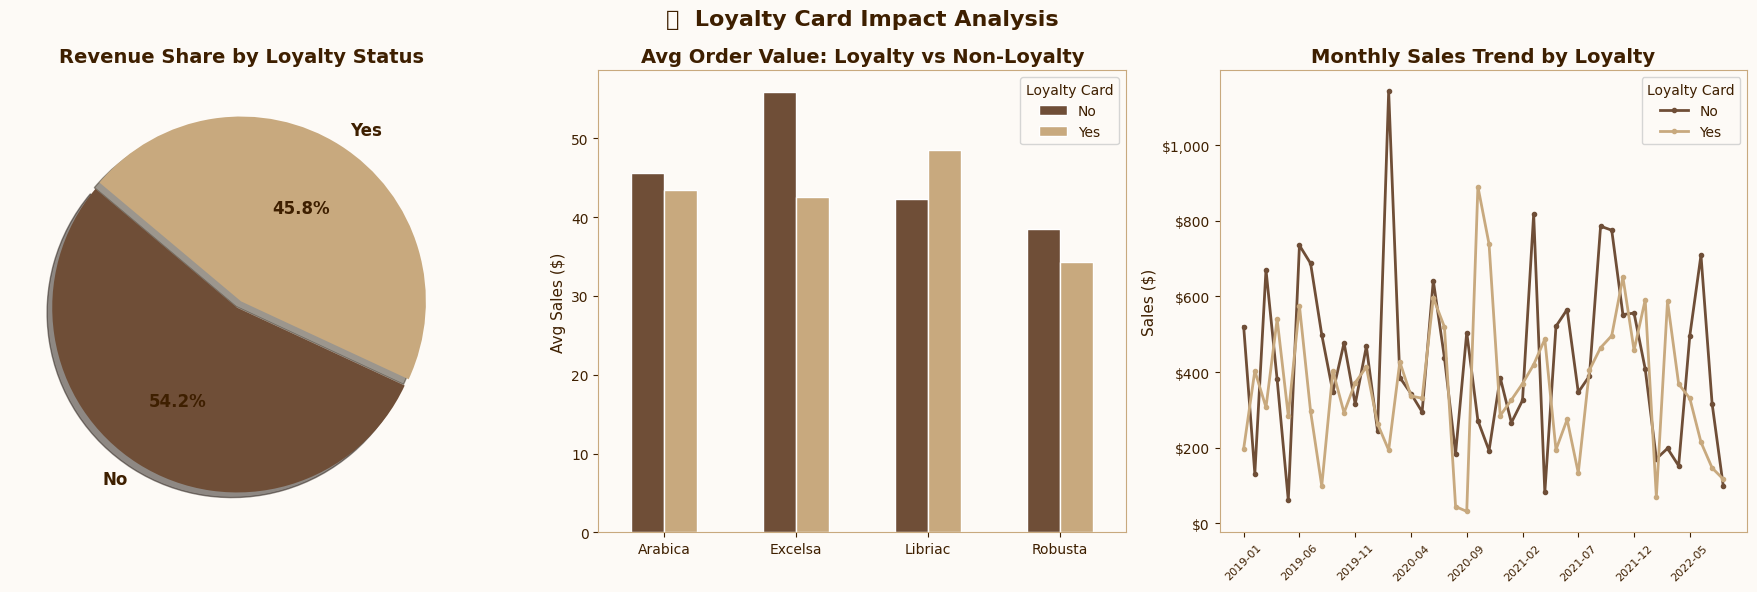


📋 Loyalty Card Summary:


,Orders,Total_Revenue,Avg_Order_Value,Total_Profit
Loyalty Card,,,,
No,393,"18,850.43",45.20,"1,866.43"
Yes,365,"15,937.72",42.28,"1,608.41"


In [16]:
# ============================================================
# LOYALTY CARD ANALYSIS
# ============================================================

if 'Loyalty Card' not in df.columns:
    print('Loyalty Card column not found — skipping section.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('💳  Loyalty Card Impact Analysis', fontsize=16, fontweight='bold')

    # ── A: Revenue share pie ───────────────────────────────
    ax = axes[0]
    loyalty_rev = df.groupby('Loyalty Card')['Sales'].sum()
    ax.pie(loyalty_rev, labels=loyalty_rev.index,
           autopct='%1.1f%%', startangle=140,
           colors=[COFFEE_PALETTE[0], COFFEE_PALETTE[1]],
           explode=(0.04, 0), shadow=True,
           textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax.set_title('Revenue Share by Loyalty Status', fontweight='bold')

    # ── B: Avg order value grouped bar ────────────────────
    ax = axes[1]
    if coffee_col in df.columns:
        piv = df.pivot_table(values='Sales', index=coffee_col,
                              columns='Loyalty Card', aggfunc='mean')
        piv.plot(kind='bar', ax=ax,
                 color=[COFFEE_PALETTE[0], COFFEE_PALETTE[1]],
                 edgecolor='white', rot=0)
        ax.set_title('Avg Order Value: Loyalty vs Non-Loyalty', fontweight='bold')
        ax.set_ylabel('Avg Sales ($)')
        ax.set_xlabel('')
        ax.legend(title='Loyalty Card')

    # ── C: Monthly loyalty vs non-loyalty trend ───────────
    ax = axes[2]
    if 'YearMonth' in df.columns:
        trend = (df.groupby(['YearMonth', 'Loyalty Card'])['Sales']
                   .sum().unstack('Loyalty Card').fillna(0))
        trend.index = trend.index.astype(str)
        for i, col in enumerate(trend.columns):
            ax.plot(trend.index, trend[col],
                    label=col, color=COFFEE_PALETTE[i],
                    linewidth=2, marker='o', markersize=3)
        step = max(1, len(trend) // 8)
        ax.set_xticks(range(0, len(trend), step))
        ax.set_xticklabels(trend.index[::step], rotation=45, fontsize=8)
        ax.set_title('Monthly Sales Trend by Loyalty', fontweight='bold')
        ax.set_ylabel('Sales ($)')
        ax.legend(title='Loyalty Card')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    plt.tight_layout()
    plt.savefig('loyalty_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary table ──────────────────────────────────────
    summary = df.groupby('Loyalty Card').agg(
        Orders=('Order ID', 'nunique') if 'Order ID' in df.columns else ('Sales', 'count'),
        Total_Revenue=('Sales', 'sum'),
        Avg_Order_Value=('Sales', 'mean'),
        Total_Profit=('Total_Profit', 'sum') if 'Total_Profit' in df.columns else ('Sales', 'sum'),
    ).round(2)
    print('\n📋 Loyalty Card Summary:')
    display(summary)

---
## 👥 Section 7 — Customer Segmentation (RFM Analysis)

In [17]:
# ============================================================
# RFM SEGMENTATION
# ============================================================

required = {'Order Date', 'Sales'}
customer_col = next((c for c in ['Customer Name', 'Customer_Name'] if c in df.columns), None)

if customer_col is None or not required.issubset(df.columns):
    print('⚠️  RFM skipped: missing required columns.')
else:
    base = df.dropna(subset=[customer_col, 'Order Date', 'Sales']).copy()
    snapshot = base['Order Date'].max() + pd.Timedelta(days=1)

    freq_agg = ('Order ID', 'nunique') if 'Order ID' in base.columns else ('Sales', 'count')

    rfm = base.groupby(customer_col).agg(
        Recency  =('Order Date', lambda x: (snapshot - x.max()).days),
        Frequency=(freq_agg[0], freq_agg[1]),
        Monetary =('Sales', 'sum')
    ).reset_index()

    # ── Scoring (1–4, higher = better for F & M, lower recency = better) ──
    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'),   q=4, labels=[4,3,2,1]).astype(int)
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)
    rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

    # ── Segment labels ────────────────────────────────────
    def segment(row):
        score = row['RFM_Score']
        r     = row['R_Score']
        if score >= 10:               return '🏆 Champions'
        elif score >= 8 and r >= 3:   return '⭐ Loyal Customers'
        elif score >= 7:              return '🔄 Potential Loyalists'
        elif r == 4 and score < 7:    return '🆕 New Customers'
        elif score >= 5 and r <= 2:   return '😴 At Risk'
        elif score < 5 and r == 1:    return '💀 Lost Customers'
        else:                         return '😐 Need Attention'

    rfm['Segment'] = rfm.apply(segment, axis=1)

    print(f'✅ RFM built for {len(rfm):,} unique customers')
    print(f'\n📋 Segment Distribution:')
    display(rfm['Segment'].value_counts())
    print(f'\n📋 Top 10 Customers by Monetary Value:')
    display(rfm.sort_values('Monetary', ascending=False).head(10).reset_index(drop=True))

✅ RFM built for 726 unique customers

📋 Segment Distribution:


Segment
🔄 Potential Loyalists    228
⭐ Loyal Customers        152
😴 At Risk                139
🏆 Champions              117
😐 Need Attention          43
💀 Lost Customers          35
🆕 New Customers           12
Name: count, dtype: int64


📋 Top 10 Customers by Monetary Value:


,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,Terri Farra,426,3,289.11,3,4,4,11,🏆 Champions
1,Nealson Cuttler,454,1,281.68,3,3,4,10,🏆 Champions
2,Don Flintiff,383,3,278.01,3,4,4,11,🏆 Champions
3,Brice Romera,679,1,246.21,2,1,4,7,🔄 Potential Loyalists
4,Ailey Brash,418,2,206.60,3,4,4,11,🏆 Champions
5,Teddi Crowthe,68,1,204.93,4,4,4,12,🏆 Champions
6,Daniel Heinonen,1122,1,204.93,1,1,4,6,😴 At Risk
7,Shelli Keynd,990,1,204.93,1,4,4,9,🔄 Potential Loyalists
8,Nanny Lush,1152,1,204.93,1,3,4,8,🔄 Potential Loyalists
9,Lacee Tanti,1211,1,204.93,1,3,4,8,🔄 Potential Loyalists


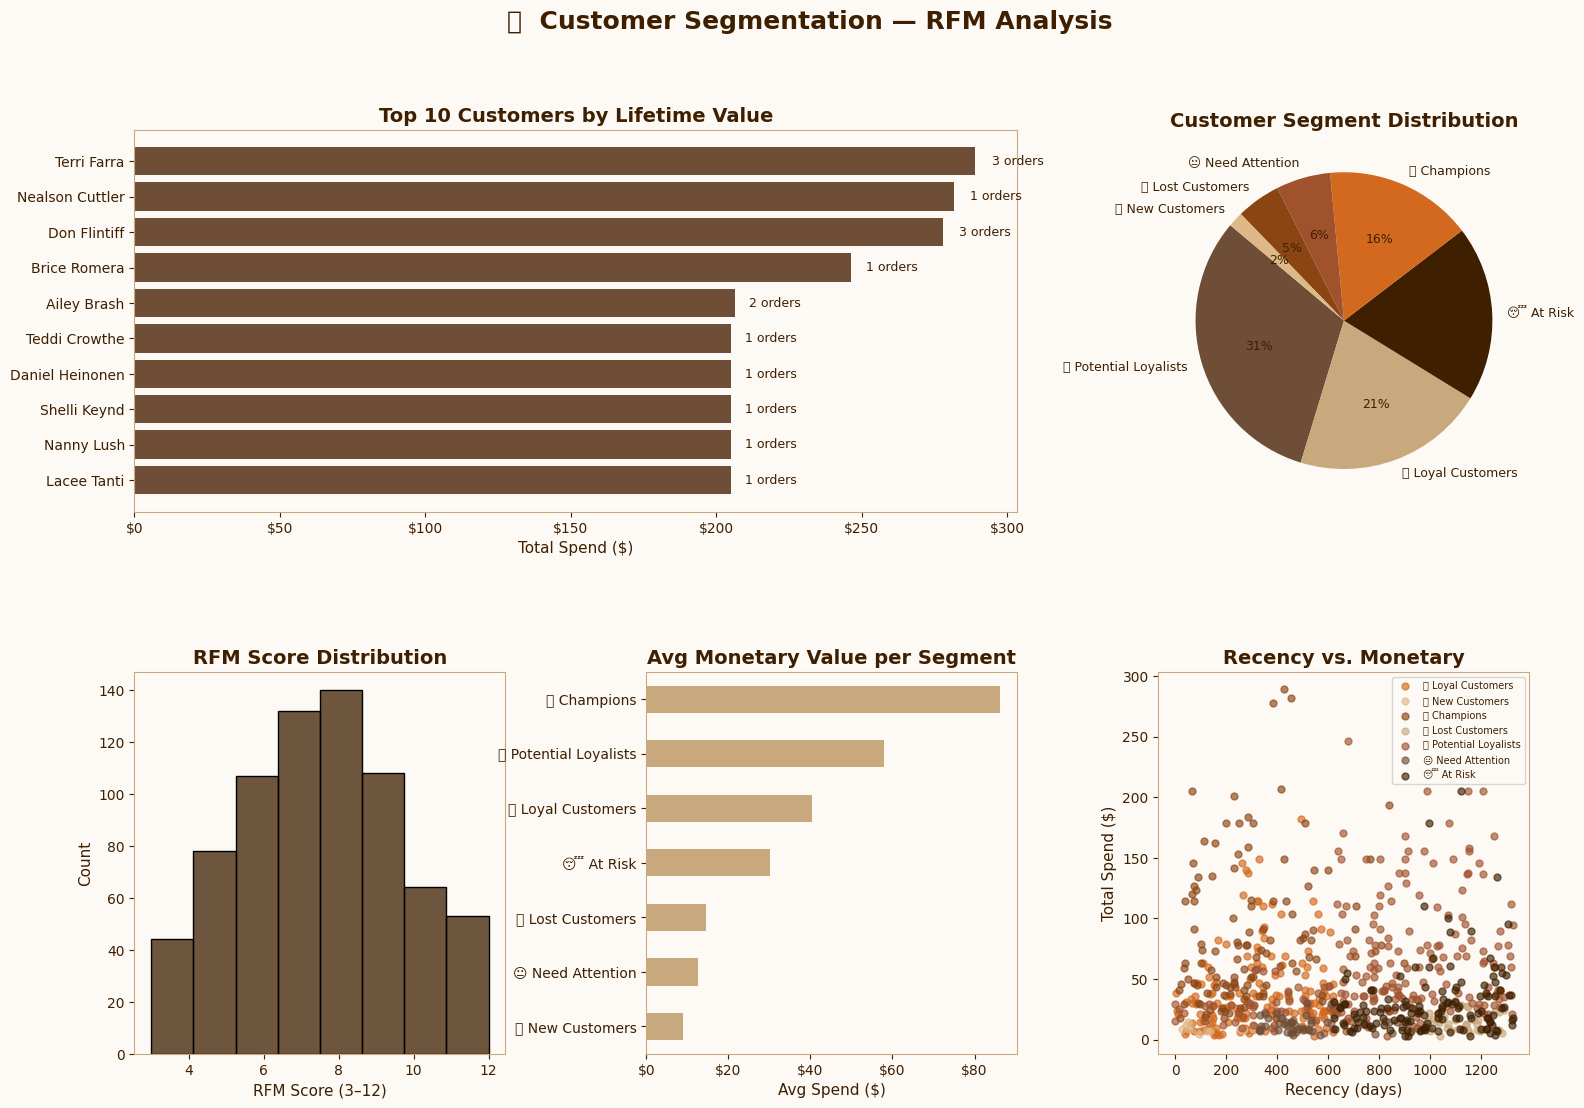

In [18]:
# ── RFM Visualizations ────────────────────────────────────

if 'rfm' not in dir():
    print('RFM not computed — skip.')
else:
    fig = plt.figure(figsize=(18, 12))
    gs  = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)
    fig.suptitle('👥  Customer Segmentation — RFM Analysis', fontsize=18, fontweight='bold')

    # ── A: Top 10 customers ───────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    top10 = rfm.sort_values('Monetary', ascending=False).head(10)
    bars = ax1.barh(top10[customer_col], top10['Monetary'],
                    color=COFFEE_PALETTE[0])
    for i, (val, freq) in enumerate(zip(top10['Monetary'], top10['Frequency'])):
        ax1.text(val * 1.01, i, f'  {int(freq)} orders', va='center',
                 fontsize=9, color='#3E1F00')
    ax1.invert_yaxis()
    ax1.set_title('Top 10 Customers by Lifetime Value', fontweight='bold')
    ax1.set_xlabel('Total Spend ($)')
    ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    # ── B: Segment distribution ───────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    seg_counts = rfm['Segment'].value_counts()
    ax2.pie(seg_counts, labels=seg_counts.index,
            autopct='%1.0f%%', startangle=140,
            colors=COFFEE_PALETTE[:len(seg_counts)],
            textprops={'fontsize': 9})
    ax2.set_title('Customer Segment Distribution', fontweight='bold')

    # ── C: RFM Score histogram ────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    sns.histplot(rfm['RFM_Score'], bins=8, kde=False,
                 color=COFFEE_PALETTE[2], ax=ax3)
    ax3.set_title('RFM Score Distribution', fontweight='bold')
    ax3.set_xlabel('RFM Score (3–12)')

    # ── D: Monetary by segment ────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    seg_money = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)
    seg_money.plot(kind='barh', ax=ax4, color=COFFEE_PALETTE[1])
    ax4.set_title('Avg Monetary Value per Segment', fontweight='bold')
    ax4.set_xlabel('Avg Spend ($)')
    ax4.set_ylabel('')
    ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    # ── E: Recency vs Monetary scatter ────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    seg_unique = rfm['Segment'].unique()
    color_map  = {s: COFFEE_PALETTE[i % len(COFFEE_PALETTE)] for i, s in enumerate(seg_unique)}
    for seg, grp in rfm.groupby('Segment'):
        ax5.scatter(grp['Recency'], grp['Monetary'],
                    label=seg, alpha=0.65, s=25,
                    color=color_map[seg])
    ax5.set_title('Recency vs. Monetary', fontweight='bold')
    ax5.set_xlabel('Recency (days)')
    ax5.set_ylabel('Total Spend ($)')
    ax5.legend(fontsize=7, loc='upper right')

    plt.savefig('rfm_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 🏆 Section 8 — Advanced Bonus Charts

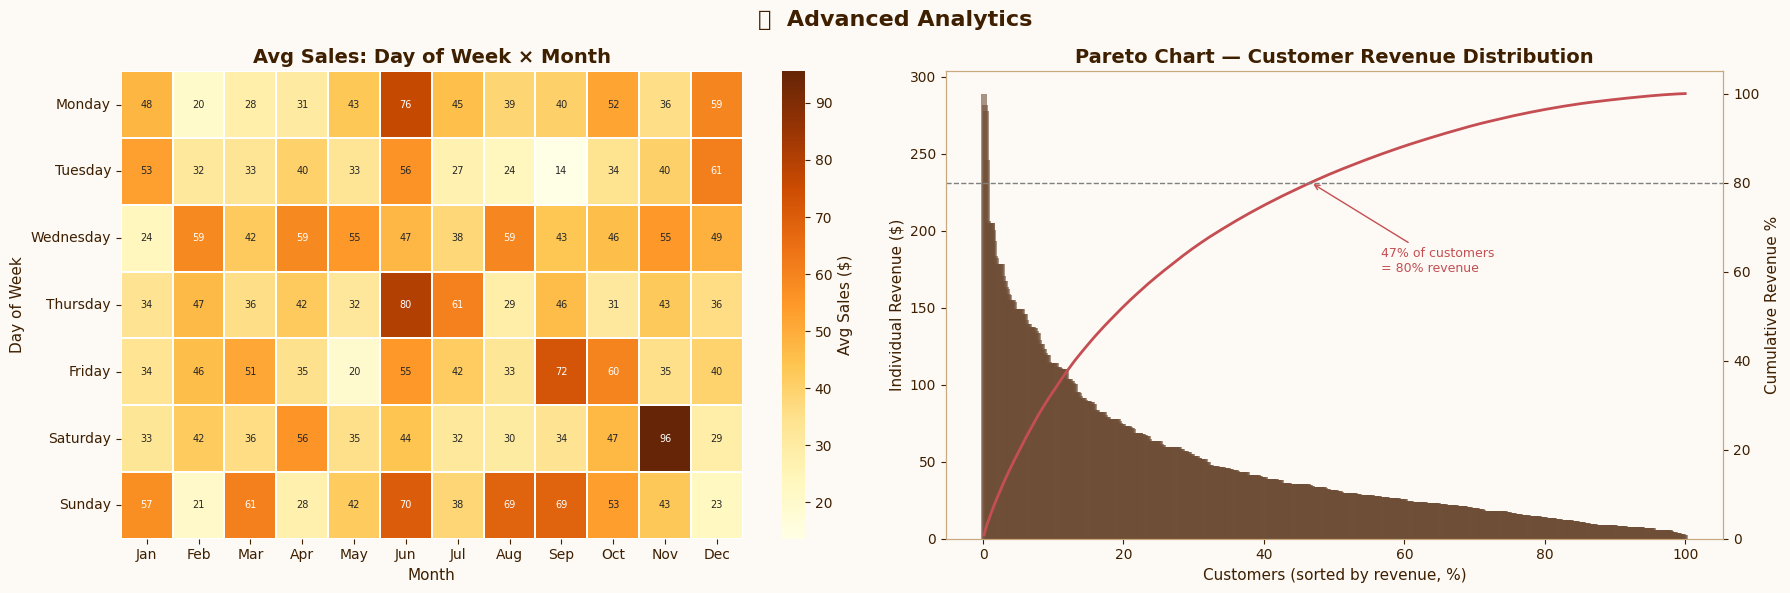

In [19]:
# ============================================================
# BONUS: Heat-map (Month × Day) + Pareto Chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('🔬  Advanced Analytics', fontsize=16, fontweight='bold')

# ── A: Month × Day heatmap ────────────────────────────────
ax = axes[0]
if {'Month', 'Day_Name'}.issubset(df.columns) and 'Sales' in df.columns:
    pivot_heat = df.pivot_table(values='Sales', index='Day_Name',
                                 columns='Month_Num', aggfunc='mean', fill_value=0)
    pivot_heat.index = pd.CategoricalIndex(
        pivot_heat.index,
        categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
        ordered=True
    )
    pivot_heat = pivot_heat.sort_index()
    month_abbr = {i: m[:3] for i, m in enumerate(['','Jan','Feb','Mar','Apr','May','Jun',
                                                     'Jul','Aug','Sep','Oct','Nov','Dec'])}
    pivot_heat.columns = [month_abbr.get(c, c) for c in pivot_heat.columns]
    sns.heatmap(pivot_heat, cmap='YlOrBr', ax=ax, linewidths=0.3,
                fmt='.0f', annot=True, annot_kws={'size': 7},
                cbar_kws={'label': 'Avg Sales ($)'})
    ax.set_title('Avg Sales: Day of Week × Month', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Day of Week')

# ── B: Pareto chart (80/20 rule on customers) ─────────────
ax = axes[1]
if 'rfm' in dir():
    pareto = rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)
    pareto['cumulative_pct'] = (pareto['Monetary'].cumsum() / pareto['Monetary'].sum() * 100)
    pareto['customer_pct']   = (pareto.index + 1) / len(pareto) * 100

    ax.bar(pareto['customer_pct'], pareto['Monetary'],
           width=0.8, color=COFFEE_PALETTE[0], alpha=0.6, label='Revenue')
    ax2_pareto = ax.twinx()
    ax2_pareto.plot(pareto['customer_pct'], pareto['cumulative_pct'],
                    color='#C44E52', linewidth=2, label='Cumulative %')
    ax2_pareto.axhline(80, color='gray', linestyle='--', linewidth=1)
    ax2_pareto.set_ylabel('Cumulative Revenue %')
    ax2_pareto.set_ylim(0, 105)
    ax.set_title('Pareto Chart — Customer Revenue Distribution', fontweight='bold')
    ax.set_xlabel('Customers (sorted by revenue, %)')
    ax.set_ylabel('Individual Revenue ($)')

    # 80% line annotation
    idx_80 = pareto[pareto['cumulative_pct'] >= 80].iloc[0]['customer_pct']
    ax2_pareto.annotate(f'{idx_80:.0f}% of customers\n= 80% revenue',
                        xy=(idx_80, 80), xytext=(idx_80 + 10, 60),
                        arrowprops=dict(arrowstyle='->', color='#C44E52'),
                        fontsize=9, color='#C44E52')

plt.tight_layout()
plt.savefig('advanced_charts.png', dpi=150, bbox_inches='tight')
plt.show()

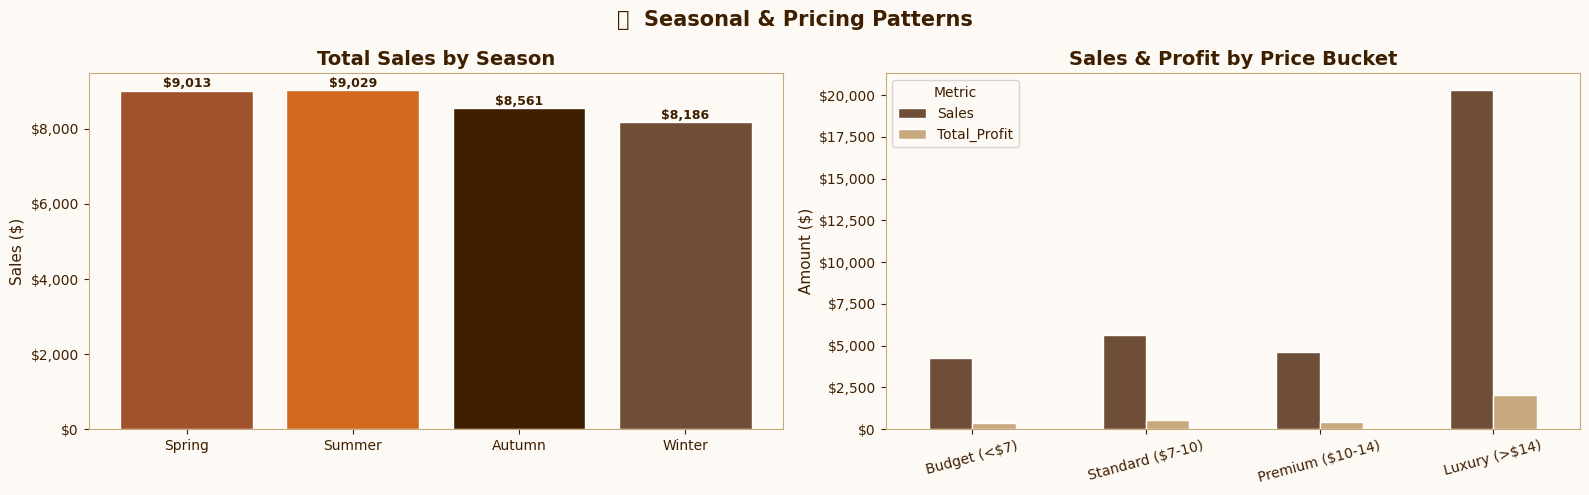

In [20]:
# ── Seasonal + Price bucket analysis ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🍂  Seasonal & Pricing Patterns', fontsize=15, fontweight='bold')

ax = axes[0]
if 'Season' in df.columns and 'Sales' in df.columns:
    season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
    season_sales = df.groupby('Season')['Sales'].sum().reindex(season_order).fillna(0)
    colors_s = [COFFEE_PALETTE[4], COFFEE_PALETTE[3], COFFEE_PALETTE[2], COFFEE_PALETTE[0]]
    ax.bar(season_sales.index, season_sales.values, color=colors_s, edgecolor='white')
    ax.set_title('Total Sales by Season', fontweight='bold')
    ax.set_ylabel('Sales ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    for i, v in enumerate(season_sales.values):
        ax.text(i, v * 1.01, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax = axes[1]
if 'Price_Bucket' in df.columns and 'Sales' in df.columns:
    pb = df.groupby('Price_Bucket', observed=True)[['Sales', 'Total_Profit']].sum()
    pb.plot(kind='bar', ax=ax,
            color=[COFFEE_PALETTE[0], COFFEE_PALETTE[1]],
            edgecolor='white', rot=15)
    ax.set_title('Sales & Profit by Price Bucket', fontweight='bold')
    ax.set_ylabel('Amount ($)')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.legend(title='Metric')

plt.tight_layout()
plt.savefig('seasonal_pricing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💡 Section 9 — Business Insights & Actionable Recommendations

In [21]:
# ============================================================
# AUTO-GENERATED INSIGHT REPORT
# ============================================================

print('=' * 65)
print('  ☕  COFFEE ANALYTICS — BUSINESS INSIGHTS REPORT')
print('=' * 65)

# ── Product Insights ──────────────────────────────────────
if coffee_col in df.columns and 'Sales' in df.columns:
    top_type   = df.groupby(coffee_col)['Sales'].sum().idxmax()
    low_margin = None
    if 'Profit_Margin_Pct' in df.columns:
        low_margin = df.groupby(coffee_col)['Profit_Margin_Pct'].mean().idxmin()
    print(f'\n📌 PRODUCT INSIGHTS')
    print(f'   • Highest revenue coffee type : {top_type}')
    if low_margin:
        print(f'   • Lowest avg profit margin type: {low_margin} — consider repricing or replacing')

# ── Time Insights ─────────────────────────────────────────
if 'Day_Name' in df.columns:
    peak_day = df['Day_Name'].value_counts().idxmax()
    slow_day = df['Day_Name'].value_counts().idxmin()
    print(f'\n📌 TIME & DEMAND INSIGHTS')
    print(f'   • Busiest day   : {peak_day} — increase staff & prep inventory')
    print(f'   • Slowest day   : {slow_day} — run targeted promo or happy-hour deals')

if 'Month' in df.columns:
    peak_month = df.groupby('Month')['Sales'].sum().idxmax()
    slow_month = df.groupby('Month')['Sales'].sum().idxmin()
    print(f'   • Best month    : {peak_month} — stock up and run loyalty rewards')
    print(f'   • Worst month   : {slow_month} — seasonal campaign recommended')

# ── Loyalty Insights ─────────────────────────────────────
if 'Loyalty Card' in df.columns:
    loy_rev   = df.groupby('Loyalty Card')['Sales'].sum()
    loy_share = loy_rev.get('Yes', 0) / loy_rev.sum() * 100
    print(f'\n📌 LOYALTY CARD INSIGHTS')
    print(f'   • Loyalty card holders drive {loy_share:.1f}% of total revenue')
    print(f'   • Action: At-checkout "instant 10% off" to convert non-holders')

# ── RFM Insights ─────────────────────────────────────────
if 'rfm' in dir():
    champions  = rfm[rfm['Segment'] == '🏆 Champions']
    at_risk    = rfm[rfm['Segment'] == '😴 At Risk']
    print(f'\n📌 CUSTOMER SEGMENTATION INSIGHTS')
    print(f'   • Champions ({len(champions)} customers): send VIP early-access offers')
    print(f'   • At-Risk   ({len(at_risk)} customers)  : re-engage with "We miss you" 15% discount')
    top3 = rfm.sort_values('Monetary', ascending=False).head(3)[customer_col].tolist()
    print(f'   • Top 3 VIP customers: {top3}')

# ── Geographic Insights ───────────────────────────────────
if country_col in df.columns:
    top_country = df.groupby(country_col)['Sales'].sum().idxmax()
    print(f'\n📌 GEOGRAPHIC INSIGHTS')
    print(f'   • Top revenue country: {top_country}')
    if 'City' in df.columns:
        top_city = df.groupby('City')['Sales'].sum().idxmax()
        print(f'   • Top revenue city   : {top_city}')

print(f'\n{"="*65}')
print('  RECOMMENDED KPI DASHBOARD METRICS TO TRACK MONTHLY:')
print('  1. Total Revenue & MoM % change')
print('  2. Avg Order Value (AOV)')
print('  3. Loyalty Card Conversion Rate')
print('  4. Top 10 Customer Revenue Contribution %')
print('  5. At-Risk Customer Count (Recency > 180 days)')
print(f'  {"="*60}')

  ☕  COFFEE ANALYTICS — BUSINESS INSIGHTS REPORT

📌 PRODUCT INSIGHTS
   • Highest revenue coffee type : Excelsa
   • Lowest avg profit margin type: Robusta — consider repricing or replacing

📌 TIME & DEMAND INSIGHTS
   • Busiest day   : Friday — increase staff & prep inventory
   • Slowest day   : Saturday — run targeted promo or happy-hour deals
   • Best month    : June — stock up and run loyalty rewards
   • Worst month   : August — seasonal campaign recommended

📌 LOYALTY CARD INSIGHTS
   • Loyalty card holders drive 45.8% of total revenue
   • Action: At-checkout "instant 10% off" to convert non-holders

📌 CUSTOMER SEGMENTATION INSIGHTS
   • Champions (117 customers): send VIP early-access offers
   • At-Risk   (139 customers)  : re-engage with "We miss you" 15% discount
   • Top 3 VIP customers: ['Terri Farra', 'Nealson Cuttler', 'Don Flintiff']

📌 GEOGRAPHIC INSIGHTS
   • Top revenue country: United States
   • Top revenue city   : Washington

  RECOMMENDED KPI DASHBOARD METRICS

---
## ✅ Section 10 — Export Processed Data

In [ ]:
# ============================================================
# EXPORT CLEAN DATA + RFM TABLE
# ============================================================

df.to_csv('coffee_clean_master.csv', index=False)
print('✅ Exported: coffee_clean_master.csv')

if 'rfm' in dir():
    rfm.to_csv('coffee_rfm_segments.csv', index=False)
    print('✅ Exported: coffee_rfm_segments.csv')

print(f'\n📋 Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n🎉  Notebook complete — all sections executed successfully!')

---

## 📌 Final Summary

This notebook executed a **complete analytics workflow** on the Coffee Sales dataset:

| Section | What Was Done |
|---------|---------------|
| Data Loading | Auto-detects local / Kaggle paths, inspects all sheets |
| Data Quality | Null heatmaps, duplicate checks, dtype audit per table |
| Cleaning & Merging | 3-table join (orders + customers + products), coercion, dedup |
| Feature Engineering | 15+ columns: time, season, profit margin, price buckets, RFM scores |
| Product EDA | Sales vs. profit by type, roast, size, top SKUs |
| Time-Series EDA | Monthly/quarterly trend, year comparison, day-of-week, seasonality |
| Geographic EDA | Revenue by country and top 10 cities |
| Distribution EDA | Histograms, box plots, violin plots, correlation matrix |
| Loyalty Analysis | Revenue share, AOV comparison, monthly trend by card status |
| RFM Segmentation | 7-tier segments, top 10 customers, Pareto 80/20 analysis |
| Business Insights | Auto-generated report with actionable recommendations |
| Export | Clean CSV + RFM segment CSV saved |

---
*☕ Thank you for reading — if this helped you, please upvote on Kaggle!*